<a href="https://colab.research.google.com/github/gibranfp/CursoAprendizajeProfundo/blob/2025-1/notebooks/5d_dcgan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generación de imágenes mediante DCGAN
En esta libreta se programa y entrena una red generativa adversaria convolucional profundo (DCGAN) para la generación de imágenes de rostros.

In [ ]:
from math import sqrt, floor, ceil

import numpy as np
import matplotlib.pyplot as plt

import torch as th
from torch import nn
from torch.utils.data import DataLoader

import torchvision as tv
import torchvision.transforms as T

N_EPOCAS = 10
T_LOTE = 128
T_EMB = 100
IMG_SIZE = 64
N_MUESTRAS_IMG = 32
FREQ_GENVIS = 2

np.random.seed(42)
th.manual_seed(42)

## Conjunto de imágenes
Se instancia la clase predefinida en `torchvision` del conjunto de imágenes de rostros CelebA, redimensionando las imágenes, convirtiéndolas a `Tensor` y escalando sus valores a un rango de $-1$ a $1$.

In [ ]:
tr = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE),
                         antialias = True),
                T.ToTensor(),
                T.Normalize(mean = (0.5, 0.5, 0.5),
                            std = (0.5, 0.5, 0.5))])
ds = tv.datasets.CelebA('./root',
                        split = 'all',
                        download = True,
                        transform = tr)
dl = DataLoader(ds,
                batch_size = T_LOTE,
                shuffle = True,
                drop_last = True,
                num_workers = 4)

it_dl = iter(dl)
lote = next(it_dl)
print(f'Imágenes = {lote[0].shape}, Categorías = {lote[1].shape}')

Files already downloaded and verified
Imágenes = torch.Size([128, 3, 64, 64]), Categorías = torch.Size([128, 40])


Se crea una función para visualizar una rejilla de imágenes.

In [ ]:
def muestra_imagenes(imgs):
  t_muestra = imgs.shape[0]
  n_filas = floor(sqrt(t_muestra))
  n_cols = ceil(sqrt(t_muestra))

  fig, ax = plt.subplots(nrows = n_filas, ncols = n_cols)

  for i in range(n_filas):
    for j in range(n_cols):
      idx = i * n_filas + j
      ax[i, j].imshow(imgs[idx])
      ax[i, j].axis('off')

  fig.subplots_adjust(wspace=-0.5, hspace=0)
  plt.show()

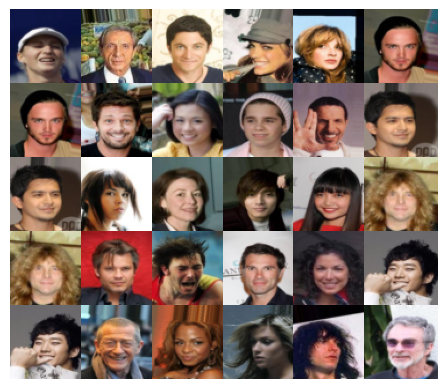

In [ ]:
muestra_imagenes(lote[0][:N_MUESTRAS_IMG].permute(0, 2, 3, 1).numpy() * 0.5 + 0.5)

## Inicializador
En el artículo de DCGAN ([Radford et al. 2016](https://arxiv.org/abs/1511.06434])), se menciona que todos los pesos se inicializan a partir de una distribución Normal con media de 0 y desviación estándar de 0.02. Para llevar a cabo esto, definimos la siguiente función:

In [ ]:
def weights_init(m):
  classname = m.__class__.__name__
  if classname.find('Conv') != -1:
    nn.init.normal_(m.weight.data, 0.0, 0.02)
  elif classname.find('BatchNorm') != -1:
    nn.init.normal_(m.weight.data, 1.0, 0.02)
    nn.init.constant_(m.bias.data, 0)

## Generador
El vector de entrada ($z$) al generador se proyecta mediante una capa lineal, cuya salida se pasa por una capa de normalización por lotes y se redimensiona para formar un mapa de $4 \times 4 \times C$, donde $C$ es el número de canales inicial. Este mapa se procesa de forma secuencial por capas de convoluciones transpuestas seguidas por capas de normalización por lotes, excepto en la última capa de convolución transpuesta. Después de cada capa de normalización por lotes se aplica la función de activación ReLU, mientras que en la  última convolución transpuesta se aplica una función de activación tangente hiperbólica.

In [ ]:
class Generador(nn.Module):
  def __init__(self,
               t_emb,
               nf = 1024):
    super(Generador, self).__init__()

    self.nf = nf
    self.t_emb = t_emb

    self.proj = nn.Linear(t_emb, 4 * 4 * nf, bias = False)
    self.bn_proj = nn.BatchNorm1d(4 * 4 * nf)

    self.bloque1 = nn.Sequential(nn.ConvTranspose2d(nf, nf // 2, 4, 2, 1, bias = False),
                                 nn.BatchNorm2d(nf // 2))
    self.bloque2 = nn.Sequential(nn.ConvTranspose2d(nf // 2, nf // 4, 4, 2, 1, bias = False),
                                 nn.BatchNorm2d(nf // 4))
    self.bloque3 = nn.Sequential(nn.ConvTranspose2d(nf // 4, nf // 8, 4, 2, 1, bias = False),
                                 nn.BatchNorm2d(nf // 8))
    self.output = nn.ConvTranspose2d(nf // 8, 3, 4, 2, 1, bias = False)

  def forward(self, x):
    x = self.proj(x)
    x = nn.functional.relu(self.bn_proj(x))
    x = x.reshape(-1, self.nf, 4, 4)

    x = nn.functional.relu(self.bloque1(x))
    x = nn.functional.relu(self.bloque2(x))
    x = nn.functional.relu(self.bloque3(x))
    x = nn.functional.tanh(self.output(x))

    return x


In [ ]:
gen = Generador(T_EMB, 512).apply(weights_init)
gen(th.rand((T_LOTE, T_EMB))).shape

torch.Size([128, 3, 64, 64])

## Discriminador
El discriminador tiene una arquitectura estándar de red convolucional, compuesta por capas convolucionales seguidas por capas de normalización por lotes y funciones de activación Leaky ReLU. El mapa de características resultantes de las capas anteriores se convierte a un vector para finalmente pasarlo por una sola neurona sigmoide.

In [ ]:
class Discriminador(nn.Module):
  def __init__(self,
               nf = 1024):
    super(Discriminador, self).__init__()

    self.conv1 = nn.Conv2d(3, nf // 8, 4, 2, 1, bias = False)
    self.bn1 = nn.BatchNorm2d(nf // 8)
    self.conv2 = nn.Conv2d(nf // 8, nf // 4, 4, 2, 1, bias = False)
    self.bn2 = nn.BatchNorm2d(nf // 4)
    self.conv3 = nn.Conv2d(nf // 4, nf // 2, 4, 2, 1, bias = False)
    self.bn3 = nn.BatchNorm2d(nf // 2)
    self.conv4 = nn.Conv2d(nf // 2, nf, 4, 2, 1, bias = False)
    self.bn4 = nn.BatchNorm2d(nf)

    self.output = nn.Linear(nf * 4 * 4, 1, bias = False)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = nn.functional.leaky_relu(x, negative_slope = 0.2)

    x = self.conv2(x)
    x = self.bn2(x)
    x = nn.functional.leaky_relu(x, negative_slope = 0.2)

    x = self.conv3(x)
    x = self.bn3(x)
    x = nn.functional.leaky_relu(x, negative_slope = 0.2)

    x = self.conv4(x)
    x = self.bn4(x)
    x = nn.functional.leaky_relu(x, negative_slope = 0.2)

    x = self.output(x.flatten(start_dim = 1))
    return x

In [ ]:
dis = Discriminador(512).apply(weights_init)
dis(gen(th.rand((T_LOTE, T_EMB)))).shape

torch.Size([128, 1])

## Función de pérdida
La función de pérdida empleada está dada por

$$
\begin{align*}
  \mathcal{L}_{{D}} = & -\frac{1}{2} \mathbb{E}_{\mathbf{x}}\left[\log \{ {{D}_{\boldsymbol{\Theta}}}(\mathbf{x})\}\right] - \frac{1}{2} \mathbb{E}_\mathbf{z} \left[\log \{1-{D}_{\boldsymbol{\Theta}}({G}_{\boldsymbol{\Phi}}(\mathbf{z}))\}\right]\\
  \mathcal{L}_{{G}} = & - \frac{1}{2} \mathbb{E}_\mathbf{z} \left[\log\{{D}_{\boldsymbol{\Theta}}({G}_{\boldsymbol{\Phi}}(\mathbf{z}))\}\right]
\end{align*}
$$

donde $\boldsymbol{\Theta}$ y $\boldsymbol{\Phi}$ son los parámetros del discriminador y del generador, respectivamente.

In [ ]:
class PerdidaGAN:
  def __init__(self):
    self.ecc = nn.BCEWithLogitsLoss()

  def gen(self, falsas):
    return self.ecc(falsas, th.ones_like(falsas))

  def dis(self, reales, falsas):
    perdida_real = self.ecc(reales, th.ones_like(reales))
    perdida_falsa = self.ecc(falsas, th.zeros_like(falsas))
    return perdida_real + perdida_falsa

## Entrenamiento
Para cada paso de entrenamiento, se realiza lo siguiente:

1. Se carga un lote de imágenes reales.
2. Se genera un lote de imágenes generadas.
3. Se pasa por el discriminador el lote de imágenes reales
4. Se pasa por el discriminador el lote de imágenes generadas desconectadas del grafo de cómputo debido a que no se van a obtener los gradientes respecto al generador.
5. Se calcula la pérdida del discriminador.
6. Se obtienen los gradientes de la pérdida respecto a los parámetros del discriminador.
7. Se pasa por el discriminador el lote de imágenes generadas conectadas al grafo de cómputo.
8. Se calcula la pérdida del generador.
9. Se obtienen los gradientes de la pérdida respecto a los parámetros del generador.
10. Se actualizan los parámetros tanto el discriminador como el generador.  

In [ ]:
def paso(gen,
         dis,
         fp,
         opt_gen,
         opt_dis,
         X,
         disp):
    opt_dis.zero_grad()
    opt_gen.zero_grad()

    Z = th.randn((T_LOTE, T_EMB), device = disp)
    X_gen = gen(Z)
    X_gen_detached = X_gen.detach()

    reales = dis(X).view(-1)
    falsas_detached = dis(X_gen_detached).view(-1)
    perdida_dis = fp.dis(reales, falsas_detached)
    perdida_dis.backward()

    falsas = dis(X_gen).view(-1)
    perdida_gen = fp.gen(falsas)
    perdida_gen.backward()

    opt_dis.step()
    opt_gen.step()

    with th.no_grad():
      perdida_gen_paso = perdida_gen.cpu().item()
      perdida_dis_paso = perdida_dis.cpu().item()

    return perdida_gen_paso, perdida_dis_paso

En la siguiente función, se define el ciclo principal de entrenamiento:

In [ ]:
def entrena(gen,
            dis,
            fp,
            opt_gen,
            opt_dis,
            dl,
            n_epocas,
            disp,
            freq_vis = 5):

  hist = {
          'perdida_gen': np.zeros(n_epocas),
          'perdida_dis': np.zeros(n_epocas)

  }

  lst_img_gen = []
  for e in range(n_epocas):
    gen.train()
    dis.train()
    for X,_ in dl:
      X = X.to(disp)
      perdida_paso_gen, perdida_paso_dis = paso(gen,
                                                dis,
                                                fp,
                                                opt_gen,
                                                opt_dis,
                                                X,
                                                disp)
      hist['perdida_gen'][e] += perdida_paso_gen
      hist['perdida_dis'][e] += perdida_paso_dis

    print(f'Época {e}/{n_epocas}: '
          f'Pérdida G = {hist["perdida_gen"][e]:.3f}, '
          f'Pérdida D = {hist["perdida_dis"][e]:.3f}')

    # guardamos un lote de imágenes generadas cada cierto número de épocas
    if e % freq_vis == 0:
      gen.eval()
      with th.no_grad():
        Z = th.randn((T_LOTE, T_EMB), device = disp)
        X_gen = gen(Z).permute(0, 2, 3, 1)
        X_vis = X_gen[:N_MUESTRAS_IMG].cpu().numpy() * 0.5 + 0.5
        lst_img_gen.append(X_vis)

  return gen, dis, hist, lst_img_gen

Se instancia un optimizador para el generador, otro más para el discriminador y la función de pérdida y se entrena la GAN.

In [ ]:
opt_gen = th.optim.Adam(gen.parameters(),
                        lr = 2e-4, betas = (0.5, 0.999))
opt_dis = th.optim.Adam(dis.parameters(),
                        lr = 2e-4, betas = (0.5, 0.999))

fp = PerdidaGAN()
gen.to('cuda:1')
dis.to('cuda:1')
gen, dis, hist, lst_img_gen = entrena(gen, dis, fp, opt_gen, opt_dis,
                                       dl, N_EPOCAS, 'cuda:1', FREQ_GENVIS)


Época 0/10: Pérdida G = 934.921, Pérdida D = 1803.146
Época 1/10: Pérdida G = 894.606, Pérdida D = 1812.302
Época 2/10: Pérdida G = 900.457, Pérdida D = 1797.093
Época 3/10: Pérdida G = 892.391, Pérdida D = 1814.007
Época 4/10: Pérdida G = 890.613, Pérdida D = 1816.441
Época 5/10: Pérdida G = 894.559, Pérdida D = 1810.728
Época 6/10: Pérdida G = 900.280, Pérdida D = 1795.499
Época 7/10: Pérdida G = 913.944, Pérdida D = 1760.680
Época 8/10: Pérdida G = 933.950, Pérdida D = 1705.500
Época 9/10: Pérdida G = 942.594, Pérdida D = 1692.530


Se grafican la pérdida del generador y del discriminador.

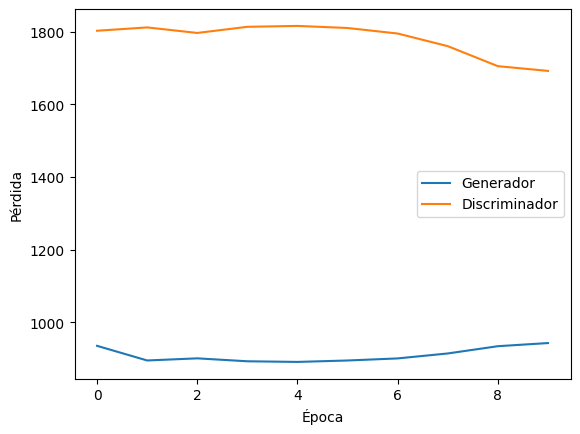

In [ ]:
plt.plot(hist['perdida_gen'], label = 'Generador')
plt.plot(hist['perdida_dis'], label = 'Discriminador')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

Visualizamos los lotes de imágenes generadas guardadas.

Época 1


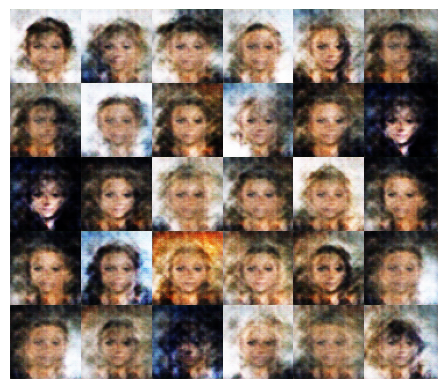

Época 3


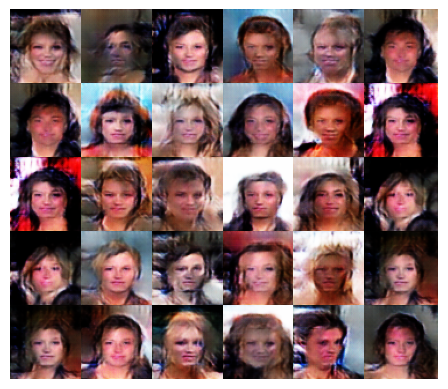

Época 5


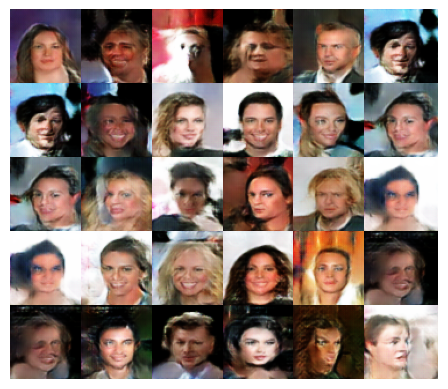

Época 7


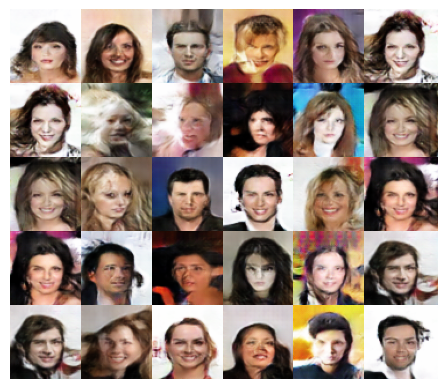

Época 9


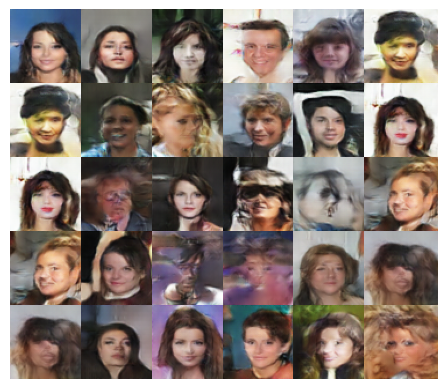

In [ ]:
for e,imgs in enumerate(lst_img_gen):
  print(f'Época {e * FREQ_GENVIS + 1}')
  muestra_imagenes(imgs)